### Source 
https://www.kaggle.com/code/yusaku5739/visualization-of-gene-expression-using-umap

# Gene expression visualization using UMAP

>UMAP (Uniform Manifold Approximation and Projection) is a novel manifold learning technique for dimension reduction. UMAP is constructed from a theoretical framework based in Riemannian geometry and algebraic topology. The result is a practical scalable algorithm that is applicable to real world data. The UMAP algorithm is competitive with t-SNE for visualization quality, and arguably preserves more of the global structure with superior run time performance. Furthermore, UMAP has no computational restrictions on embedding dimension, making it viable as a general purpose dimension reduction technique for machine learning
(McInnes, Leland; Healy, John; Melville, James (2018-12-07). "Uniform manifold approximation and projection for dimension reduction". arXiv:1802.03426.)

### Please Upvote if you Find this Useful :)

In [1]:
!pip install umap-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import umap

/home/mgodl/gradient/PCA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774188314.757458    7537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774188314.762675    7537 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774188314.920150    7537 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774188316.433

In [3]:
df = pd.read_parquet("../data/de_train.parquet")
df_gene_exp = df.drop(columns=["cell_type","sm_name", "sm_lincs_id", "SMILES", "control"])
df_info = df[["cell_type","sm_name", "sm_lincs_id", "SMILES", "control"]]

/home/mgodl/gradient/PCA/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


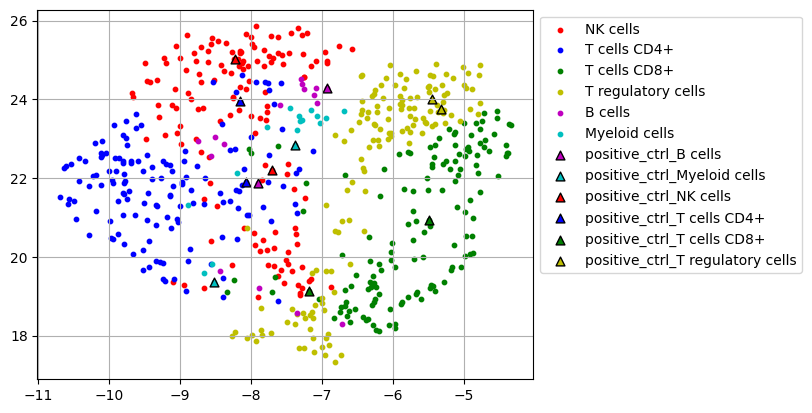

In [6]:
# do UMAP clustering
mapper = umap.UMAP(random_state=42,
                   n_neighbors=100,
                   min_dist=0.4,
                   metric="correlation")
embedding = mapper.fit_transform(df_gene_exp)

embedding_x = embedding[:, 0]
embedding_y = embedding[:, 1]


# plot UMAP
colors=["r", "b", "g", "y", "m", "c", "k", "w"]
dic_c = {}

for (cell,c) in zip(df_info["cell_type"].unique(), colors):
    dic_c[cell]=c
    cell_i = df_info[df_info["cell_type"]==cell].index.to_list()
    plt.scatter(embedding_x[cell_i], embedding_y[cell_i], label=cell, s=10, color=c)
    
cont = df_info[df_info["control"]==True]
for cell in cont["cell_type"].unique():
    i = cont.query("cell_type==@cell").index.to_list()
    plt.scatter(embedding_x[i], embedding_y[i], label=f"positive_ctrl_{cell}", marker="^",color=dic_c[cell], s=40, edgecolors="black")

plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#plt.title()
plt.show()